In [ ]:
import os
import subprocess
from datetime import datetime, timedelta
import calendar
from pathlib import Path
import requests
import pandas as pd
from datetime import datetime, timedelta
import geopandas as gpd
import fiona
from shapely.geometry import box
import geopandas as gpd
import matplotlib.pyplot as plt
import boto3

In [25]:


YEAR = 2026
MONTH = 7   # 6 = June, 7 = July

start = datetime(YEAR, MONTH, 1)
last_day = calendar.monthrange(YEAR, MONTH)[1]
end = datetime(YEAR, MONTH, last_day)

print(f"Search window: {start.date()} -> {end.date()} (YEAR={YEAR}, MONTH={MONTH})")


Search window: 2026-07-01 -> 2026-07-31 (YEAR=2026, MONTH=7)


In [26]:


# ----------------------------
# Paths
# ----------------------------

BASE = Path("/data-store/iplant/home/samiksha23/SCE-CU/sentinel2_data")
NEW_DATA = BASE / "new_data"

# ----------------------------
# AWS
# ----------------------------

AWS_ENDPOINT = "https://eodata.dataspace.copernicus.eu"

BUCKET = "eodata"

# ----------------------------
# Desired bands
# ----------------------------

BANDS = [
    "B02","B03","B04",
    "B05","B06","B07",
    "B08","B11","B12"
]

In [27]:
# AOI = {
#     "type": "Polygon",
#     "coordinates": [[
#         [-120.708008, 32.53],
#         [-113.975687, 32.53],
#         [-113.975687, 38.395343],
#         [-120.708008, 38.395343],
#         [-120.708008, 32.53]
#     ]]
# }

AOI = {
    "type": "Polygon",
    "coordinates": [[
        [-122.80, 32.50],
        [-114.75, 32.50],
        [-114.75, 37.10],
        [-122.80, 37.10],
        [-122.80, 32.50]
    ]]
}

In [28]:


# Uses start/end from the YEAR/MONTH cell above — re-run that cell first
url = "https://stac.dataspace.copernicus.eu/v1/search"

records = []
date = start

print(f"Searching STAC from {start.date()} to {end.date()} ...")

while date <= end:

    start_time = date.strftime("%Y-%m-%dT00:00:00Z")
    end_time   = date.strftime("%Y-%m-%dT23:59:59Z")

    payload = {
        "collections": ["sentinel-2-l2a"],
        "intersects": AOI,
        "datetime": f"{start_time}/{end_time}",
        "limit": 200,
        "fields": {
            "include": [
                "id",
                "properties.datetime",
                "properties.eo:cloud_cover",
                "properties.s2:mgrs_tile",
                "properties.s2:product_uri"
            ]
        }
    }

    r = requests.post(url, json=payload)

    if r.status_code != 200:
        print(date.date(), r.text)
        date += timedelta(days=1)
        continue

    data = r.json()

    for feature in data["features"]:
        props = feature["properties"]
        records.append({
            "id": feature["id"],
            "date": props["datetime"][:10],
            "tile": feature["id"].split("_")[5][1:],
            "cloud": props.get("eo:cloud_cover"),
            "product": props.get("s2:product_uri")
        })

    print(date.date(), "done")
    date += timedelta(days=1)

df = pd.DataFrame(records)
print(f"Total products: {len(df)}")
if len(df):
    print("Date range in df:", df["date"].min(), "->", df["date"].max())


Searching STAC from 2026-07-01 to 2026-07-31 ...
2026-07-01 done
2026-07-02 done
2026-07-03 done
2026-07-04 done
2026-07-05 done
2026-07-06 done
2026-07-07 done
2026-07-08 done
2026-07-09 done
2026-07-10 done
2026-07-11 done
2026-07-12 done
2026-07-13 done
2026-07-14 done
2026-07-15 done
2026-07-16 done
2026-07-17 done
2026-07-18 done
2026-07-19 done
2026-07-20 done
2026-07-21 done
2026-07-22 done
2026-07-23 done
2026-07-24 done
2026-07-25 done
2026-07-26 done
2026-07-27 done
2026-07-28 done
2026-07-29 done
2026-07-30 done
2026-07-31 done
Total products: 779
Date range in df: 2026-07-01 -> 2026-07-31


In [29]:
!gocmd get i:/iplant/home/samiksha23/SCE-CU/sentinel2_data/new_data/S2A_OPER_GIP_TILPAR_MPC__20151209T095117_V20150622T000000_21000101T000000_B00.kml

fiona.drvsupport.supported_drivers["LIBKML"] = "rw"

tiles = gpd.read_file("S2A_OPER_GIP_TILPAR_MPC__20151209T095117_V20150622T000000_21000101T000000_B00.kml", driver="LIBKML")

tiles.head()

,Name,description,timestamp,begin,end,altitudeMode,tessellate,extrude,visibility,drawOrder,icon,snippet,geometry
0,01CCV,TILE PROPERTIES<br><table border=0 cellpadding...,NaT,NaT,NaT,None,-1,0,-1,None,None,,GEOMETRYCOLLECTION Z (POLYGON Z ((180.00000 -7...
1,01CDH,TILE PROPERTIES<br><table border=0 cellpadding...,NaT,NaT,NaT,None,-1,0,-1,None,None,,GEOMETRYCOLLECTION Z (POLYGON Z ((180.00000 -8...
2,01CDJ,TILE PROPERTIES<br><table border=0 cellpadding...,NaT,NaT,NaT,None,-1,0,-1,None,None,,GEOMETRYCOLLECTION Z (POLYGON Z ((180.00000 -8...
3,01CDK,TILE PROPERTIES<br><table border=0 cellpadding...,NaT,NaT,NaT,None,-1,0,-1,None,None,,GEOMETRYCOLLECTION Z (POLYGON Z ((180.00000 -8...
4,01CDL,TILE PROPERTIES<br><table border=0 cellpadding...,NaT,NaT,NaT,None,-1,0,-1,None,None,,GEOMETRYCOLLECTION Z (POLYGON Z ((180.00000 -8...


In [30]:


aoi = box(
    -120.708008,
    32.53,
    -113.975687,
    38.395343
)

aoi = gpd.GeoDataFrame(
    geometry=[aoi],
    crs="EPSG:4326"
)

In [31]:
selected_tiles = tiles[tiles.intersects(aoi.geometry.iloc[0])]

In [32]:
selected_tiles["Name"]

9364     10SFD
9365     10SFE
9366     10SFF
9367     10SFG
9368     10SFH
         ...  
11218    12STD
11219    12STE
11220    12STF
11221    12STG
11222    12STH
Name: Name, Length: 65, dtype: object

In [33]:
selected_tiles = selected_tiles.to_crs(3857)
aoi = aoi.to_crs(3857)

In [34]:
coverage = (
    selected_tiles.unary_union
    .intersection(aoi.geometry.iloc[0])
    .area
    /
    aoi.geometry.iloc[0].area
) * 100

print(coverage)

100.0


In [35]:
rows = []

for date, grp in df.groupby("date"):

    tiles_today = grp["tile"].unique()

    polys = selected_tiles[
        selected_tiles["Name"].isin(tiles_today)
    ]

    cov = (
        polys.unary_union
        .intersection(aoi.geometry.iloc[0])
        .area
        /
        aoi.geometry.iloc[0].area
    ) * 100

    rows.append({
        "date": date,
        "coverage": cov
    })

coverage_df = pd.DataFrame(rows)

In [36]:
summary = (
    df.groupby("date")
      .agg(
          n_images=("id", "count"),
          n_tiles=("tile", "nunique"),
          mean_cloud=("cloud", "mean"),
          max_cloud=("cloud", "max")
      )
      .reset_index()
)

summary = summary.merge(
    coverage_df,
    on="date"
)

# Prefer high AOI coverage, more tiles, then lower cloud
summary = summary.sort_values(
    ["coverage", "n_tiles", "mean_cloud"],
    ascending=[False, False, True]
).reset_index(drop=True)

summary

,date,n_images,n_tiles,mean_cloud,max_cloud,coverage
0,2026-07-28,55,41,21.881636,99.84,82.111276
1,2026-07-21,60,47,22.825667,82.28,77.541906
2,2026-07-01,60,47,37.688833,100.00,77.541906
3,2026-07-06,35,31,11.716286,93.48,67.833996
4,2026-07-31,31,31,15.630000,96.78,67.833996
5,2026-07-11,31,31,36.357097,100.00,67.833996
6,2026-07-16,30,30,9.877000,36.14,65.366845
7,2026-07-26,30,30,57.354333,97.64,65.366845
8,2026-07-08,25,24,3.378800,50.34,46.071721
9,2026-07-15,32,24,7.611250,29.91,46.071721


In [37]:
# Automatically pick best date: most coverage + tiles, least cloud
best = summary.iloc[0]["date"]

tiles = sorted(df[df["date"] == best]["tile"].unique())
tiles_plot = selected_tiles[
    selected_tiles["Name"].isin(tiles_today)
]

print("best date:", best)
print("coverage:", round(summary.iloc[0]["coverage"], 2))
print("n_tiles:", int(summary.iloc[0]["n_tiles"]))
print("mean_cloud:", round(summary.iloc[0]["mean_cloud"], 2))
print(len(tiles))
print(tiles)

best date: 2026-07-28
coverage: 82.11
n_tiles: 41
mean_cloud: 21.88
41
['10SGB', '11SKR', '11SKS', '11SKT', '11SKU', '11SKV', '11SLA', '11SLB', '11SLR', '11SLS', '11SLT', '11SLU', '11SLV', '11SMA', '11SMB', '11SMR', '11SMS', '11SMT', '11SMU', '11SMV', '11SNA', '11SNB', '11SNR', '11SNS', '11SNT', '11SNU', '11SNV', '11SPA', '11SPB', '11SPR', '11SPS', '11SPT', '11SPU', '11SPV', '11SQA', '11SQB', '11SQR', '11SQS', '11SQT', '11SQU', '11SQV']


In [38]:
# best already set from summary above
best

'2026-07-28'

In [39]:
tiles_today = df[df["date"] == best]["tile"].unique()

tiles_today

array(['11SPV', '11SPU', '11SPB', '11SPA', '11SNV', '11SNU', '11SNT',
       '11SNS', '11SNR', '11SNB', '11SNA', '11SMV', '11SMU', '11SMT',
       '11SMS', '11SMR', '11SMB', '11SMA', '11SLV', '11SLU', '11SLT',
       '11SLS', '11SLR', '11SLB', '11SLA', '11SKV', '11SKU', '11SKT',
       '11SKS', '11SKR', '10SGB', '11SQV', '11SQU', '11SQT', '11SQS',
       '11SQR', '11SQB', '11SQA', '11SPT', '11SPS', '11SPR'], dtype=object)

In [40]:
tiles_plot = selected_tiles[
    selected_tiles["Name"].isin(tiles_today)
]

In [41]:
print(len(tiles_plot))

39


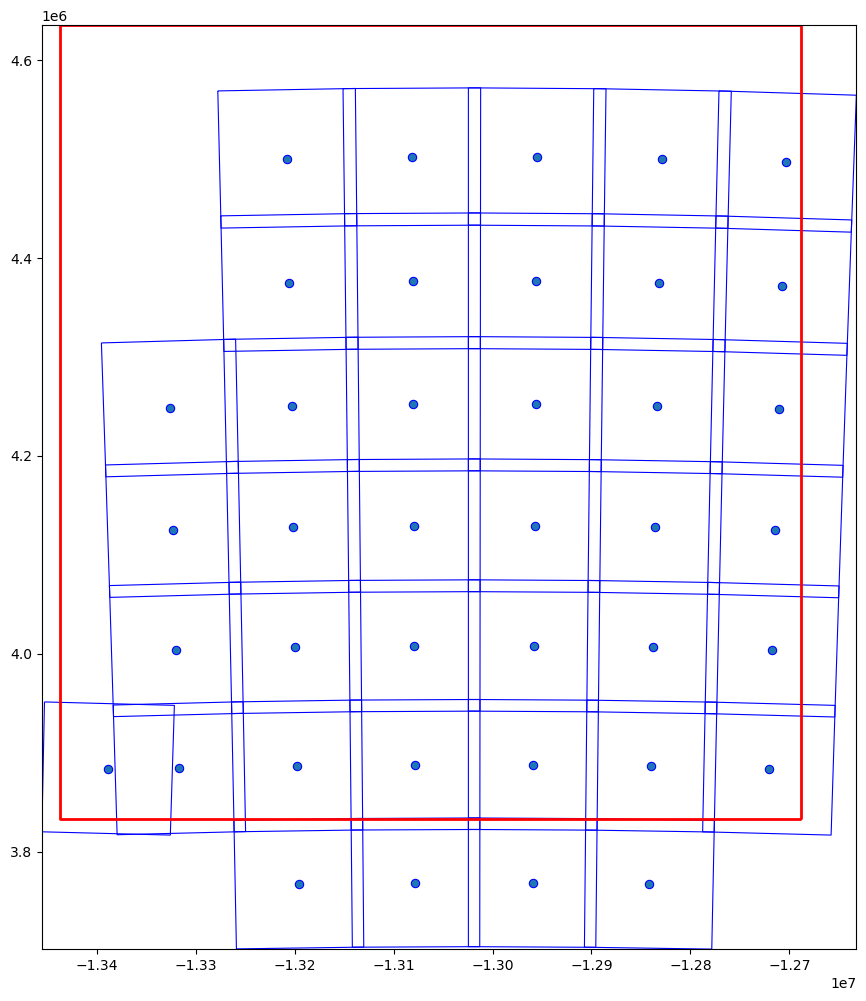

In [42]:


fig, ax = plt.subplots(figsize=(12,12))

tiles_plot.plot(
    ax=ax,
    facecolor="none",
    edgecolor="blue",
    linewidth=0.8
)

aoi.plot(
    ax=ax,
    facecolor="none",
    edgecolor="red",
    linewidth=2
)

ax.set_xlim(
    min(tiles_plot.total_bounds[0], aoi.total_bounds[0]),
    max(tiles_plot.total_bounds[2], aoi.total_bounds[2])
)

ax.set_ylim(
    min(tiles_plot.total_bounds[1], aoi.total_bounds[1]),
    max(tiles_plot.total_bounds[3], aoi.total_bounds[3])
)

plt.show()

## AWS

In [63]:


ACCESS_KEY = "132XINZKVGVSB23A2J4M"
SECRET_KEY = "DfpW2XIUIaQI42PxUj2Wh4u4OdAVMf9wK5Wp8Ob6"

s3 = boto3.resource(
    "s3",
    endpoint_url="https://eodata.dataspace.copernicus.eu",
    aws_access_key_id=ACCESS_KEY,
    aws_secret_access_key=SECRET_KEY,
    region_name="default"
)

bucket = s3.Bucket("eodata")

In [64]:


# Use auto-picked best date (falls back to best_date if needed)
date_str = best if "best" in globals() else str(best_date)
date = datetime.strptime(date_str, "%Y-%m-%d")

year = date.strftime("%Y")
month = date.strftime("%m")
day = date.strftime("%d")

print(date_str)

2026-07-28


In [65]:
prefix = f"Sentinel-2/MSI/L2A/{year}/{month}/{day}/"

print(prefix)

Sentinel-2/MSI/L2A/2026/07/28/


In [66]:


# ==========================================================
# PRODUCT LIST
# ==========================================================

selected = df[df["date"] == best]
products = selected["id"].drop_duplicates().tolist()

save_dir = f"/data-store/iplant/home/samiksha23/SCE-CU/sentinel2_data/new_data/{best}"
os.makedirs(save_dir, exist_ok=True)

yyyy = best[:4]
mm = best[5:7]
dd = best[8:10]

failed = []
total = len(products)

print(f"Found {total} products")

# ==========================================================
# DOWNLOAD
# ==========================================================

for i, product in enumerate(products, start=1):

    print(f"\n[{i}/{total}] Downloading {product}")

    outdir = os.path.join(save_dir, product + ".SAFE")

    try:

        subprocess.run(
            [
                "aws",
                "--endpoint-url",
                "https://eodata.dataspace.copernicus.eu",
                "s3",
                "cp",
                f"s3://eodata/Sentinel-2/MSI/L2A/{yyyy}/{mm}/{dd}/{product}.SAFE",
                outdir,
                "--recursive",
                "--only-show-errors",
            ],
            check=True,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
        )

    #     print("✅ Downloaded")
    # print("\nMissing:")
    # print("None")
    # print("\n" + "-" * 60)

        print(f"✅ [{i}/{total}] Downloaded")

    except subprocess.CalledProcessError:

        print(f"❌ [{i}/{total}] Failed to Download few items!")
        failed.append(product


    #     print("\nMissing:")
    # print(f"- {product}")
    # print("\n" + "-" * 60)

# ==========================================================
# SUMMARY
# ==========================================================

print("\n==============================")
print("Download finished.")
print("==============================")

print(f"\nTotal products : {total}")
print(f"Downloaded     : {total - len(failed)}")
print(f"Failed         : {len(failed)}")



Found 55 products

[1/55] Downloading S2A_MSIL2A_20260728T183831_N0512_R027_T11SPV_20260729T025553
✅ [1/55] Downloaded

[2/55] Downloading S2A_MSIL2A_20260728T183831_N0512_R027_T11SPU_20260729T025553
❌ [2/55] Failed

[3/55] Downloading S2A_MSIL2A_20260728T183831_N0512_R027_T11SPB_20260729T025553
❌ [3/55] Failed

[4/55] Downloading S2A_MSIL2A_20260728T183831_N0512_R027_T11SPA_20260729T025553
❌ [4/55] Failed

[5/55] Downloading S2A_MSIL2A_20260728T183831_N0512_R027_T11SNV_20260729T025553
❌ [5/55] Failed

[6/55] Downloading S2A_MSIL2A_20260728T183831_N0512_R027_T11SNU_20260729T025553
❌ [6/55] Failed

[7/55] Downloading S2A_MSIL2A_20260728T183831_N0512_R027_T11SNT_20260729T025553
❌ [7/55] Failed

[8/55] Downloading S2A_MSIL2A_20260728T183831_N0512_R027_T11SNS_20260729T025553
❌ [8/55] Failed

[9/55] Downloading S2A_MSIL2A_20260728T183831_N0512_R027_T11SNR_20260729T025553
✅ [9/55] Downloaded

[10/55] Downloading S2A_MSIL2A_20260728T183831_N0512_R027_T11SNB_20260729T025553
✅ [10/55] Downloade

OSError: [Errno 121] Remote I/O error: '/data-store/iplant/home/samiksha23/SCE-CU/sentinel2_data/new_data/2026-07-28/failed_products.txt'

In [84]:
import os
import subprocess

# ==========================================================
# SETTINGS
# ==========================================================

save_dir = f"/data-store/iplant/home/samiksha23/SCE-CU/sentinel2_data/new_data/{best}"

yyyy = best[:4]
mm = best[5:7]
dd = best[8:10]

report = []

# ==========================================================
# CHECK EACH FAILED PRODUCT
# ==========================================================

for product in failed:

    print(f"Checking {product}")

    local_root = os.path.join(save_dir, product + ".SAFE")

    report.append("=" * 80)
    report.append(product)

    if not os.path.exists(local_root):
        report.append("Folder does not exist.")
        report.append("")
        continue

    # ------------------------------------------------------
    # AWS FILE LIST
    # ------------------------------------------------------

    cmd = [
        "aws",
        "--endpoint-url",
        "https://eodata.dataspace.copernicus.eu",
        "s3",
        "ls",
        f"s3://eodata/Sentinel-2/MSI/L2A/{yyyy}/{mm}/{dd}/{product}.SAFE",
        "--recursive",
    ]

    result = subprocess.run(
        cmd,
        capture_output=True,
        text=True,
        check=True,
    )

    aws_files = set()

    for line in result.stdout.splitlines():

        if not line.strip():
            continue

        # path is the 4th column of aws s3 ls output
        path = line.split(maxsplit=3)[3]

        # Remove everything before ".SAFE/"
        if ".SAFE/" in path:
            path = path.split(".SAFE/", 1)[1]

        aws_files.add(path)

    # ------------------------------------------------------
    # LOCAL FILE LIST
    # ------------------------------------------------------

    local_files = set()

    for root, _, files in os.walk(local_root):
        for f in files:
            rel = os.path.relpath(
                os.path.join(root, f),
                local_root
            )
            local_files.add(rel)

    # ------------------------------------------------------
    # COMPARE
    # ------------------------------------------------------

    missing = sorted(aws_files - local_files)

    report.append(f"AWS files   : {len(aws_files)}")
    report.append(f"Local files : {len(local_files)}")
    report.append(f"Missing     : {len(missing)}")
    report.append("")

    if missing:
        report.extend(missing)
    else:
        report.append("No missing files.")

    report.append("")

# ==========================================================
# SAVE REPORT
# ==========================================================

report_file = os.path.join(os.getcwd(), "missing_files_report.txt")

with open(report_file, "w") as f:
    f.write("\n".join(report))

print("\n====================================")
print("Finished.")
print("====================================")
print("Report saved to:")
print(report_file)

Checking S2A_MSIL2A_20260728T183831_N0512_R027_T11SPU_20260729T025553
Checking S2A_MSIL2A_20260728T183831_N0512_R027_T11SPB_20260729T025553
Checking S2A_MSIL2A_20260728T183831_N0512_R027_T11SPA_20260729T025553
Checking S2A_MSIL2A_20260728T183831_N0512_R027_T11SNV_20260729T025553
Checking S2A_MSIL2A_20260728T183831_N0512_R027_T11SNU_20260729T025553
Checking S2A_MSIL2A_20260728T183831_N0512_R027_T11SNT_20260729T025553
Checking S2A_MSIL2A_20260728T183831_N0512_R027_T11SNS_20260729T025553
Checking S2A_MSIL2A_20260728T183831_N0512_R027_T11SMV_20260729T025553
Checking S2A_MSIL2A_20260728T183831_N0512_R027_T11SMU_20260729T025553
Checking S2A_MSIL2A_20260728T183831_N0512_R027_T11SMT_20260729T025553
Checking S2A_MSIL2A_20260728T183831_N0512_R027_T11SMS_20260729T025553
Checking S2A_MSIL2A_20260728T183831_N0512_R027_T11SMR_20260729T025553
Checking S2A_MSIL2A_20260728T183831_N0512_R027_T11SMB_20260729T025553
Checking S2A_MSIL2A_20260728T183831_N0512_R027_T11SLV_20260729T025553
Checking S2A_MSIL2A_

In [99]:
# import os
# import subprocess

# # ==========================================================
# # SETTINGS
# # ==========================================================

#  # or use your existing variable

# report_file = "missing_files_report.txt"

# save_dir = f"/data-store/iplant/home/samiksha23/SCE-CU/sentinel2_data/new_data/{best}"

# yyyy = best[:4]
# mm = best[5:7]
# dd = best[8:10]

# # ==========================================================
# # PARSE REPORT
# # ==========================================================

# downloads = []

# current_product = None

# with open(report_file) as f:

#     for line in f:

#         line = line.strip()

#         if not line:
#             continue

#         if line.startswith("S2A_") or line.startswith("S2B_"):
#             current_product = line
#             continue

#         if (
#             line.startswith("AWS")
#             or line.startswith("Local")
#             or line.startswith("Missing")
#             or line.startswith("=")
#             or line.startswith("Folder does not exist")
#             or line.startswith("No missing")
#         ):
#             continue

#         downloads.append((current_product, line))

# print(f"Found {len(downloads)} missing files.")

# # ==========================================================
# # DOWNLOAD
# # ==========================================================

# failed = []

# for i, (product, relpath) in enumerate(downloads, start=1):

#     print(f"[{i}/{len(downloads)}] {product}")
#     print("   ", relpath)

#     s3_path = (
#         f"s3://eodata/Sentinel-2/MSI/L2A/"
#         f"{yyyy}/{mm}/{dd}/{product}.SAFE/{relpath}"
#     )

#     local_path = os.path.join(
#         save_dir,
#         product + ".SAFE",
#         relpath
#     )

#     os.makedirs(os.path.dirname(local_path), exist_ok=True)

#     try:

#         subprocess.run(
#             [
#                 "aws",
#                 "--endpoint-url",
#                 "https://eodata.dataspace.copernicus.eu",
#                 "s3",
#                 "cp",
#                 s3_path,
#                 local_path,
#                 "--only-show-errors",
#             ],
#             check=True,
#         )

#         print("   ✅ Downloaded")

#     except subprocess.CalledProcessError:

#         print("   ❌ Failed")
#         failed.append((product, relpath))

# # ==========================================================
# # SUMMARY
# # ==========================================================

# print("\n===================================")
# print("Finished")
# print("===================================")

# print(f"Downloaded : {len(downloads)-len(failed)}")
# print(f"Failed     : {len(failed)}")

# if failed:

#     print("\nStill failed:")

#     for product, path in failed:
#         print(product)
#         print("   ", path)

In [87]:

# ==========================================================
# SETTINGS
# ==========================================================
#best = "2026-07-28"        # or use your existing variable
report_file = "missing_files_report.txt"

yyyy = best[:4]
mm = best[5:7]
dd = best[8:10]

tmp_root = "/tmp/sentinel_fix"

os.makedirs(tmp_root, exist_ok=True)

# ==========================================================
# PARSE REPORT
# ==========================================================

downloads = []

current_product = None

with open(report_file) as f:

    for line in f:

        line = line.strip()

        if not line:
            continue
        if (
            (line.startswith("S2A_") or line.startswith("S2B_"))
            and ".jpg" not in line
            and "/" not in line
        ):
            current_product = line
            continue
        

        if (
            line.startswith("=")
            or line.startswith("AWS")
            or line.startswith("Local")
            or line.startswith("Missing")
            or line.startswith("Folder")
            or line.startswith("No missing")
        ):
            continue

        downloads.append((current_product, line))

print(f"Found {len(downloads)} missing files.")

failed = []

# ==========================================================
# DOWNLOAD
# ==========================================================

for i, (product, relpath) in enumerate(downloads, start=1):

    print(f"[{i}/{len(downloads)}] {product}")
    print("   ", relpath)

    s3_path = (
        f"s3://eodata/Sentinel-2/MSI/L2A/"
        f"{yyyy}/{mm}/{dd}/{product}.SAFE/{relpath}"
    )

    local_path = os.path.join(
        tmp_root,
        product + ".SAFE",
        relpath
    )

    os.makedirs(os.path.dirname(local_path), exist_ok=True)

    try:

        subprocess.run(
            [
                "aws",
                "--endpoint-url",
                "https://eodata.dataspace.copernicus.eu",
                "s3",
                "cp",
                s3_path,
                local_path,
                "--only-show-errors",
            ],
            check=True,
        )

        print("   ✅ Downloaded")

    except subprocess.CalledProcessError:

        print("   ❌ Failed")
        failed.append((product, relpath))

print("\n===================================")
print("Finished downloading to /tmp")
print("===================================")

print(f"Downloaded : {len(downloads)-len(failed)}")
print(f"Failed     : {len(failed)}")

if failed:

    with open("/tmp/remaining_missing.txt","w") as f:

        for p,file in failed:
            f.write(f"{p}|{file}\n")

    print("\nRemaining failures saved to")
    print("/tmp/remaining_missing.txt")

Found 123 missing files.
[1/123] S2A_MSIL2A_20260728T183831_N0512_R027_T11SPU_20260729T025553
    GRANULE/L2A_T11SPU_A057968_20260728T183828/MTD_TL.xml
   ✅ Downloaded
[2/123] S2A_MSIL2A_20260728T183831_N0512_R027_T11SPB_20260729T025553
    GRANULE/L2A_T11SPB_A057968_20260728T183828/IMG_DATA/R20m/T11SPB_20260728T183831_B02_20m.jp2
   ✅ Downloaded
[3/123] S2A_MSIL2A_20260728T183831_N0512_R027_T11SPB_20260729T025553
    GRANULE/L2A_T11SPB_A057968_20260728T183828/IMG_DATA/R20m/T11SPB_20260728T183831_B07_20m.jp2
   ✅ Downloaded
[4/123] S2A_MSIL2A_20260728T183831_N0512_R027_T11SPB_20260729T025553
    GRANULE/L2A_T11SPB_A057968_20260728T183828/IMG_DATA/R20m/T11SPB_20260728T183831_B11_20m.jp2
   ✅ Downloaded
[5/123] S2A_MSIL2A_20260728T183831_N0512_R027_T11SPB_20260729T025553
    GRANULE/L2A_T11SPB_A057968_20260728T183828/IMG_DATA/R20m/T11SPB_20260728T183831_B8A_20m.jp2
   ✅ Downloaded
[6/123] S2A_MSIL2A_20260728T183831_N0512_R027_T11SPB_20260729T025553
    GRANULE/L2A_T11SPB_A057968_20260728

In [92]:
import os
import subprocess

# ==========================================================
# SETTINGS
# ==========================================================

tmp_root = "/tmp/sentinel_fix"

irods_dest = (
    "/iplant/home/samiksha23/"
    "SCE-CU/sentinel2_data/new_data/2026-07-28"
)

# ==========================================================
# FIND PRODUCTS
# ==========================================================

products = sorted(
    d for d in os.listdir(tmp_root)
    if d.endswith(".SAFE")
)

print(f"Found {len(products)} products to upload.\n")

failed = []

# ==========================================================
# UPLOAD
# ==========================================================

for i, product in enumerate(products, start=1):

    src = os.path.join(tmp_root, product)

    print(f"[{i}/{len(products)}] Uploading {product}")

    try:

        subprocess.run(
            [
                "gocmd",
                "put",
                "--diff",
                src,
                irods_dest,
            ],
            check=True,
        )

        print("   ✅ Uploaded")

    except subprocess.CalledProcessError as e:

        print("   ❌ Failed")
        failed.append(product)

# ==========================================================
# SUMMARY
# ==========================================================

print("\n===================================")
print("Upload complete")
print("===================================")

print(f"Uploaded : {len(products) - len(failed)}")
print(f"Failed   : {len(failed)}")

if failed:

    print("\nFailed uploads:")

    for p in failed:
        print(" -", p)

else:

    print("\n🎉 All products uploaded successfully.")

Found 38 products to upload.

[1/38] Uploading S2A_MSIL2A_20260728T183831_N0512_R027_T11SKS_20260729T025553.SAFE
skip uploading a file "/tmp/sentinel_fix/S2A_MSIL2A_20260728T183831_N0512_R027_T11SKS_20260729T025553.SAFE/GRANULE/L2A_T11SKS_A057968_20260728T183828/IMG_DATA/R20m/T11SKS_20260728T183831_B01_20m.jp2" to "/iplant/home/samiksha23/SCE-CU/sentinel2_data/new_data/2026-07-28/S2A_MSIL2A_20260728T183831_N0512_R027_T11SKS_20260729T025553.SAFE/GRANULE/L2A_T11SKS_A057968_20260728T183828/IMG_DATA/R20m/T11SKS_20260728T183831_B01_20m.jp2". The data object with the same hash already exists!
skip uploading a file "/tmp/sentinel_fix/S2A_MSIL2A_20260728T183831_N0512_R027_T11SKS_20260729T025553.SAFE/GRANULE/L2A_T11SKS_A057968_20260728T183828/IMG_DATA/R20m/T11SKS_20260728T183831_B06_20m.jp2" to "/iplant/home/samiksha23/SCE-CU/sentinel2_data/new_data/2026-07-28/S2A_MSIL2A_20260728T183831_N0512_R027_T11SKS_20260729T025553.SAFE/GRANULE/L2A_T11SKS_A057968_20260728T183828/IMG_DATA/R20m/T11SKS_202607

In [97]:
import os
import subprocess

best = "2026-07-28"

save_dir = f"/data-store/iplant/home/samiksha23/SCE-CU/sentinel2_data/new_data/{best}"

yyyy = best[:4]
mm = best[5:7]
dd = best[8:10]

products = sorted(
    d[:-5]
    for d in os.listdir(save_dir)
    if (
        d.endswith(".SAFE")
        and d.startswith(("S2A_", "S2B_"))
        and "-ql.jpg" not in d
    )
)

all_ok = True

for product in products:

    local_root = os.path.join(save_dir, product + ".SAFE")

    # AWS files
    try:
        result = subprocess.run(
            [
                "aws",
                "--endpoint-url",
                "https://eodata.dataspace.copernicus.eu",
                "s3",
                "ls",
                f"s3://eodata/Sentinel-2/MSI/L2A/{yyyy}/{mm}/{dd}/{product}.SAFE",
                "--recursive",
            ],
            capture_output=True,
            text=True,
            check=True,
        )

    except subprocess.CalledProcessError:
        print(f"\n⚠️ Could not list AWS product: {product}")
        all_ok = False
        continue

    aws_files = set()

    for line in result.stdout.splitlines():

        if not line.strip():
            continue

        path = line.split(maxsplit=3)[3]
        path = path.split(".SAFE/", 1)[1]

        aws_files.add(path)

    # Local files
    local_files = set()

    for root, _, files in os.walk(local_root):
        for f in files:
            rel = os.path.relpath(os.path.join(root, f), local_root)
            local_files.add(rel)

    missing = aws_files - local_files

    if missing:
        all_ok = False
        print(f"\n❌ {product}: {len(missing)} files missing")

        for f in sorted(missing):
            print("   ", f)

    else:
        print(f"✅ {product}")

print("\n=================================")

if all_ok:
    print("🎉 Every product matches AWS!")
else:
    print("Some products are still incomplete.")

✅ S2A_MSIL2A_20260728T183831_N0512_R027_T10SGB_20260729T025553
✅ S2A_MSIL2A_20260728T183831_N0512_R027_T11SKR_20260729T025553
✅ S2A_MSIL2A_20260728T183831_N0512_R027_T11SKS_20260729T025553
✅ S2A_MSIL2A_20260728T183831_N0512_R027_T11SKT_20260729T025553
✅ S2A_MSIL2A_20260728T183831_N0512_R027_T11SKU_20260729T025553
✅ S2A_MSIL2A_20260728T183831_N0512_R027_T11SKV_20260729T025553
✅ S2A_MSIL2A_20260728T183831_N0512_R027_T11SLA_20260729T025553
✅ S2A_MSIL2A_20260728T183831_N0512_R027_T11SLB_20260729T025553
✅ S2A_MSIL2A_20260728T183831_N0512_R027_T11SLR_20260729T025553
✅ S2A_MSIL2A_20260728T183831_N0512_R027_T11SLS_20260729T025553
✅ S2A_MSIL2A_20260728T183831_N0512_R027_T11SLT_20260729T025553
✅ S2A_MSIL2A_20260728T183831_N0512_R027_T11SLU_20260729T025553
✅ S2A_MSIL2A_20260728T183831_N0512_R027_T11SLV_20260729T025553
✅ S2A_MSIL2A_20260728T183831_N0512_R027_T11SMA_20260729T025553
✅ S2A_MSIL2A_20260728T183831_N0512_R027_T11SMB_20260729T025553
✅ S2A_MSIL2A_20260728T183831_N0512_R027_T11SMR_20260729

In [98]:
import os
import subprocess

best = "2026-07-28"

save_dir = f"/data-store/iplant/home/samiksha23/SCE-CU/sentinel2_data/new_data/{best}"

yyyy = best[:4]
mm = best[5:7]
dd = best[8:10]

# ------------------------------------------------------------------
# CyVerse products
# ------------------------------------------------------------------

cyverse_products = sorted(
    d[:-5]
    for d in os.listdir(save_dir)
    if (
        d.endswith(".SAFE")
        and d.startswith(("S2A_", "S2B_"))
        and "-ql.jpg" not in d
    )
)

print(f"CyVerse products : {len(cyverse_products)}")

# ------------------------------------------------------------------
# AWS products (only those matching the downloaded product names)
# ------------------------------------------------------------------

aws_products = []

for product in cyverse_products:

    try:
        subprocess.run(
            [
                "aws",
                "--endpoint-url",
                "https://eodata.dataspace.copernicus.eu",
                "s3",
                "ls",
                f"s3://eodata/Sentinel-2/MSI/L2A/{yyyy}/{mm}/{dd}/{product}.SAFE",
            ],
            capture_output=True,
            text=True,
            check=True,
        )

        aws_products.append(product)

    except subprocess.CalledProcessError:
        pass

print(f"AWS products      : {len(aws_products)}")

# ------------------------------------------------------------------
# Compare
# ------------------------------------------------------------------

cy_set = set(cyverse_products)
aws_set = set(aws_products)

print("\n==============================")

if cy_set == aws_set:
    print("🎉 Product lists match!")
    print(f"Total products: {len(cy_set)}")
else:
    print("❌ Product lists differ.")

    print("\nMissing from CyVerse:")
    for p in sorted(aws_set - cy_set):
        print(" ", p)

    print("\nExtra in CyVerse:")
    for p in sorted(cy_set - aws_set):
        print(" ", p)

print("==============================")

CyVerse products : 49
AWS products      : 49

🎉 Product lists match!
Total products: 49


In [ ]:
# aws --endpoint-url https://eodata.dataspace.copernicus.eu \
# s3 cp \
# s3://eodata/Sentinel-2/MSI/L2A/2026/07/28/S2A_MSIL2A_20260728T183831_N0512_R027_T11SPB_20260729T025553.SAFE \
# /data-store/iplant/home/samiksha23/SCE-CU/sentinel2_data/new_data/2026-07-28/S2A_MSIL2A_20260728T183831_N0512_R027_T11SPB_20260729T025553.SAFE \
# --recursive